Proceso terminado. Imagen guardada en: C:\Users\edwar\OneDrive\Documents\analisis_seguridad_final.png


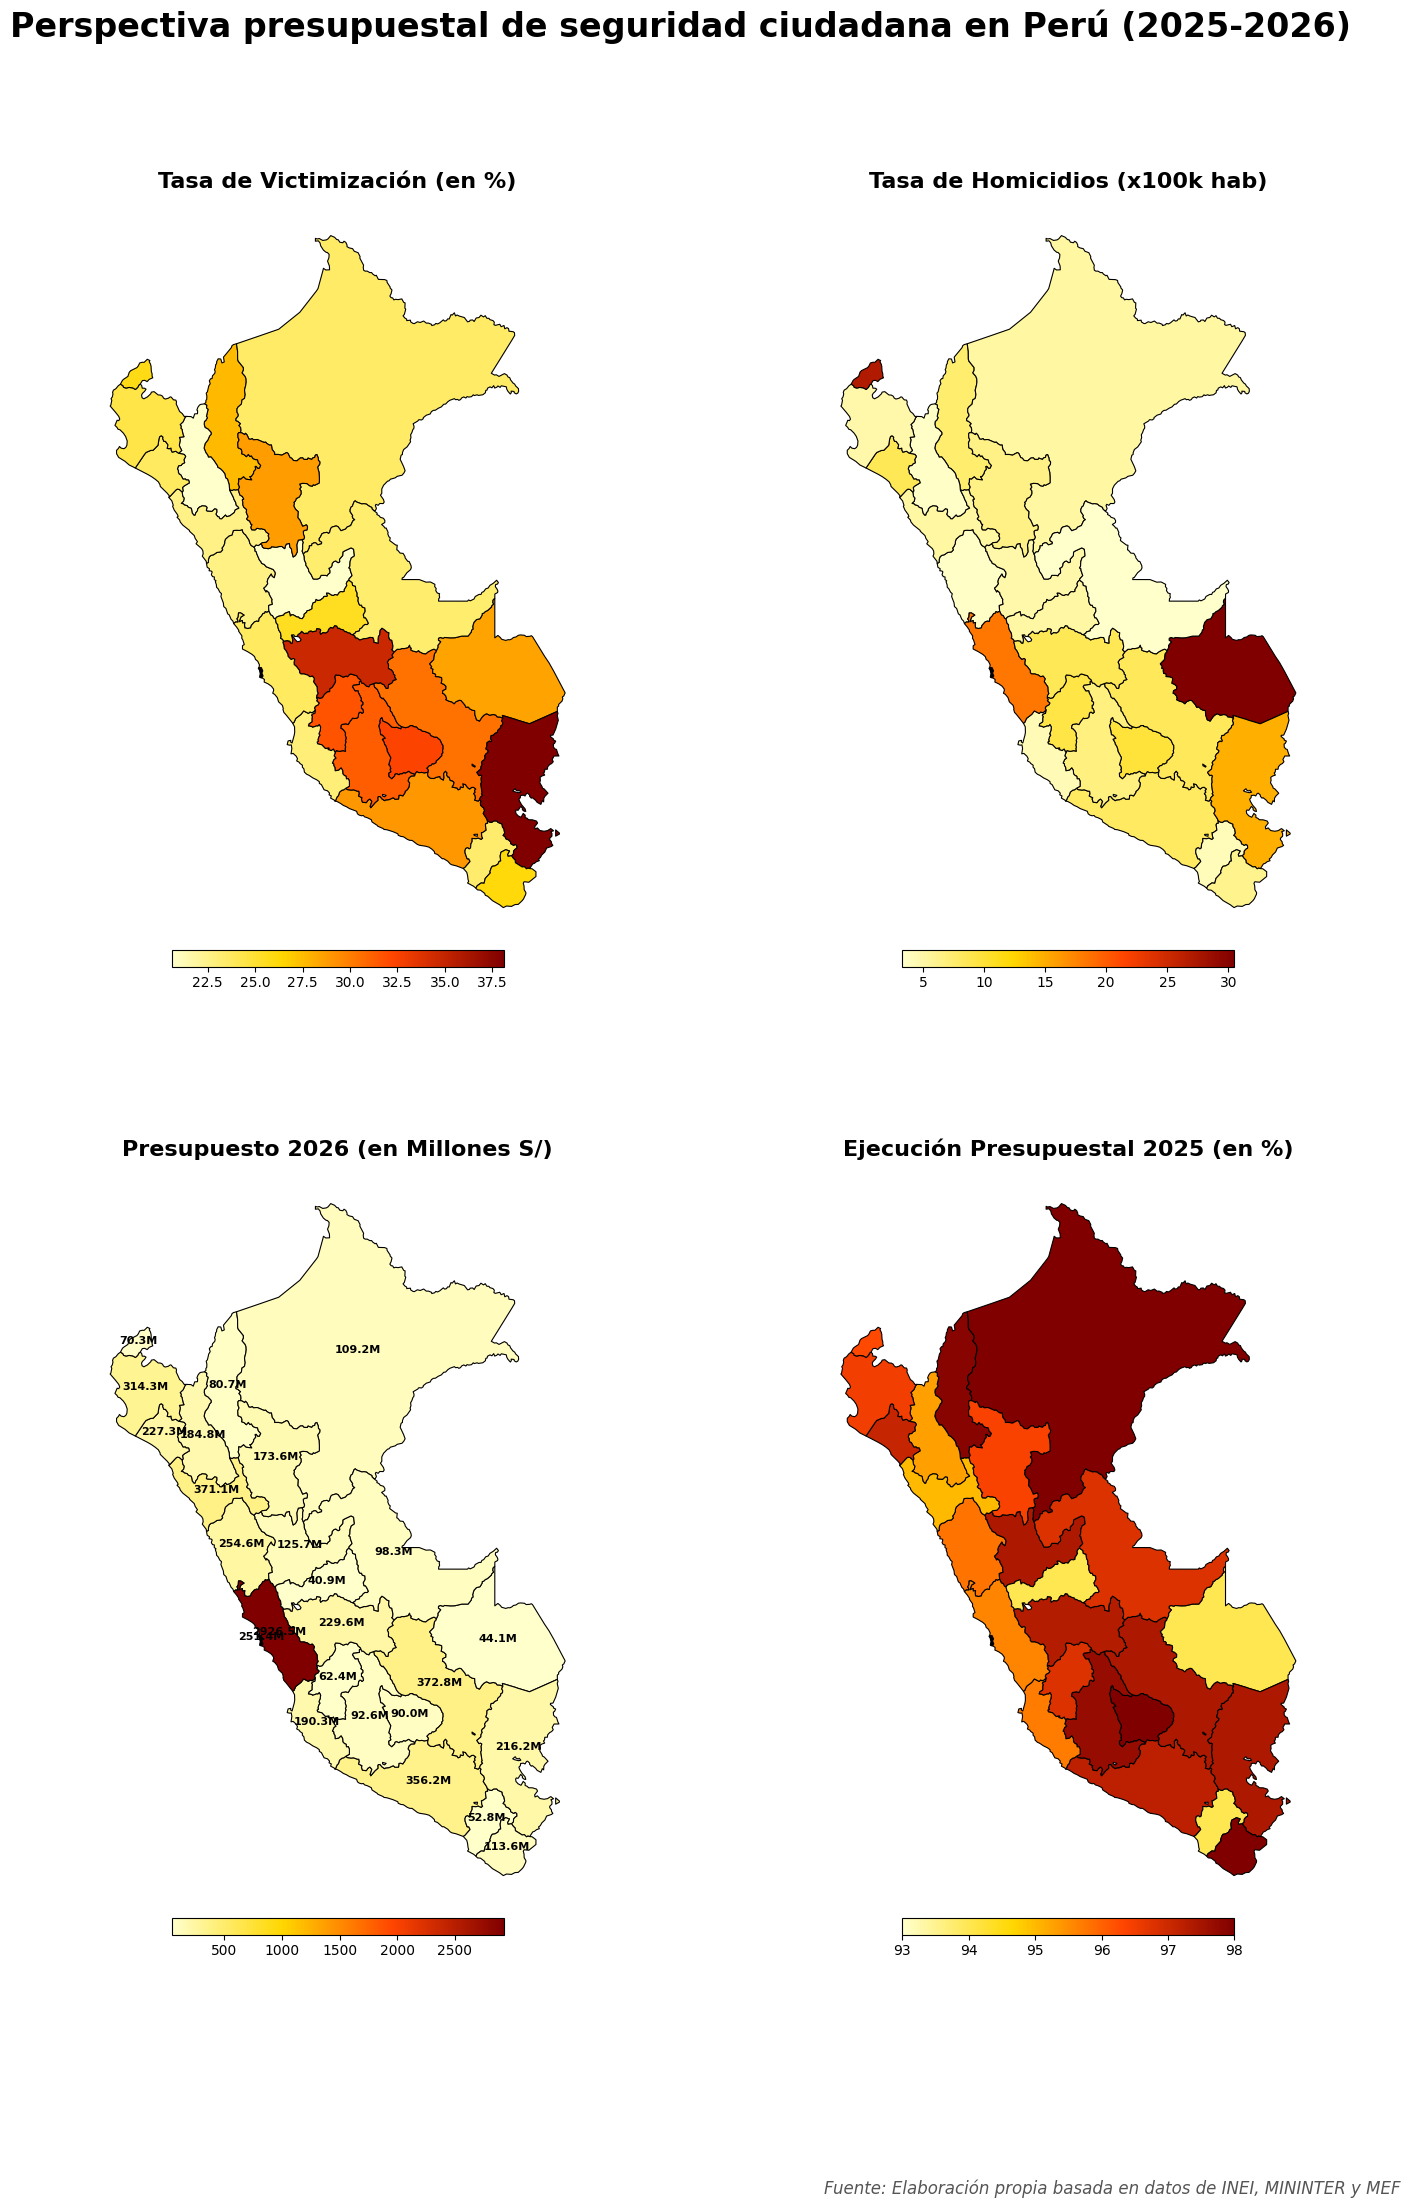

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

# 1. Ruta local del archivo
ruta_excel = r"C:\Users\edwar\OneDrive\Documents\Datos delitos pr_25_26.xlsx"

# 2. Carga y limpieza de datos
if os.path.exists(ruta_excel):
    df = pd.read_excel(ruta_excel, sheet_name='Hoja2')
    df.columns = df.columns.astype(str).str.strip().str.lower()
    
    # --- TRANSFORMACIÓN DE DATOS ---
    df['victimizacion_pct'] = df['victimizacion'] * 100
    df['ejecucion_pct'] = df['ejecucion_25'] * 100
    df['presupuesto_mllns'] = df['presupuesto_26'] / 1_000_000

    if 'departamento' not in df.columns:
        print(f"Error: No encontré la columna 'departamento'. Columnas: {list(df.columns)}")
        exit()
else:
    print("Error: No se encontró el archivo en la ruta.")
    exit()

# 3. Cargar Geometría de Departamentos
geojson_url = "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_departamental_simple.geojson"
gdf = gpd.read_file(geojson_url)

# 4. Normalizar nombres
def normalize(s):
    import unicodedata
    if pd.isna(s): return ""
    s = str(s).upper().replace('REGION ', '').strip()
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

gdf['NOMBDEP_NORM'] = gdf['NOMBDEP'].apply(normalize)
df['DEPT_NORM'] = df['departamento'].apply(normalize)

merged = gdf.merge(df, left_on='NOMBDEP_NORM', right_on='DEPT_NORM', how='left')

# 5. Escala de Color
colors = ["#FFFFCC", "#FFD700", "#FF4500", "#800000"]
cmap_custom = LinearSegmentedColormap.from_list("seguridad_peru", colors)

# 6. Generar bloque de 4 mapas (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

maps_to_plot = [
    ('victimizacion_pct', 'Tasa de Victimización (en %)', axes[0, 0]),
    ('tasa_homicidios', 'Tasa de Homicidios (x100k hab)', axes[0, 1]),
    ('presupuesto_mllns', 'Presupuesto 2026 (en Millones S/)', axes[1, 0]),
    ('ejecucion_pct', 'Ejecución Presupuestal 2025 (en %)', axes[1, 1])
]

for col, title, ax in maps_to_plot:
    if col in merged.columns:
        merged.plot(
            column=col, 
            cmap=cmap_custom, 
            linewidth=0.8, 
            ax=ax, 
            edgecolor='black', 
            legend=True,
            legend_kwds={'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.01}
        )
        
        callao = merged[merged['NOMBDEP_NORM'] == 'CALLAO']
        if not callao.empty:
            callao.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

        if col == 'presupuesto_mllns':
            for idx, row in merged.iterrows():
                if pd.notnull(row[col]):
                    centro = row.geometry.centroid
                    ax.annotate(text=f"{row[col]:.1f}M", 
                                xy=(centro.x, centro.y),
                                horizontalalignment='center',
                                fontsize=8, 
                                fontweight='bold',
                                color='black') 
    else:
        ax.text(0.5, 0.5, f'Columna "{col}" no encontrada', ha='center')
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Perspectiva presupuestal de seguridad ciudadana en Perú (2025-2026)', 
             fontsize=24, y=0.96, fontweight='bold')

# --- NUEVA NOTA AL PIE DE PÁGINA ---
fig.text(0.9, 0.05, 'Fuente: Elaboración propia basada en datos de INEI, MININTER y MEF', 
         ha='right', fontsize=12, style='italic', color='#555555')

# Guardar resultado
output_path = os.path.join(os.path.dirname(ruta_excel), "analisis_seguridad_final.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Proceso terminado. Imagen guardada en: {output_path}")
plt.show()